# Evaluation of Text Models

## 1 Overview

This notebook compares six pretrained text-emotion models on the CancerEmo dataset. The models are evaluated using five common emotion labels which are anger, fear, joy, sadness and surprise. Anticipation, trust and disgust are omitted from the main comparison because they are not supported by every candidate model.

The validation split is used to compare models and select the best model based on macro-F1 as the primary metric. Accuracy, precision, recall, model loading time and inference time are also logged. The selected model is the only model evaluated on the testing split. We do not perform any training or fine-tuning. This notebook provides a reproducible comparison of the candidate text-emotion models.


## 2 Importing Libraries

Libraries required for loading the CancerEmo files, executing the pre-trained models, calculating evaluation metrics, measuring execution time and displaying the confusion matrices are imported.

In [1]:
# importing libraries
from pathlib import Path
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, f1_score, precision_score, recall_score
from transformers import pipeline

c:\Users\Subathra\OneDrive\Desktop\cm3020_Final_Year_project\CM3020_Final_Year_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The libraries needed to assess text models were imported successfully.

## 3 Evaluation Settings and Candidate Models

The evaluation settings, dataset locations and six candidate text-emotion models are defined below. The models were selected to compare different transformer architectures and model sizes using the same validation and testing procedure.

In [2]:
# result reproducible
SEED = 42
MAX_LENGTH = 256
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
# use gpu when it is available
device = 0 if torch.cuda.is_available() else -1

In [4]:
# dataset folder
validation_folder = Path("../../data/processed/canceremo/validation")
testing_folder = Path("../../data/processed/canceremo/testing")

In [5]:
# output folder to store results
output_folder = Path("outputs/text")
# create the folder
output_folder.mkdir(parents=True, exist_ok=True)

In [6]:
# Emotions supported by all six models
emotions = ["anger", "fear", "joy", "sadness", "surprise"]

In [7]:
# Candidate text models
models = {
    "DistilBERT": {
        "model_id": ("bhadresh-savani/distilbert-base-uncased-emotion"),
        "training_data": "dair-ai/emotion",
        "batch_size": 32
    },

    "BERT": {
        "model_id": ("bhadresh-savani/bert-base-uncased-emotion"),
        "training_data": "dair-ai/emotion",
        "batch_size": 16
    },

    "RoBERTa": {
        "model_id": ("bhadresh-savani/roberta-base-emotion"),
        "training_data": "dair-ai/emotion",
        "batch_size": 16
    },

    "DistilRoBERTa": {
        "model_id": ("j-hartmann/emotion-english-distilroberta-base"),
        "training_data": "Six external emotion datasets",
        "batch_size": 16
    },

    "BERT-Nateraw": {
        "model_id": ("nateraw/bert-base-uncased-emotion"),
        "training_data": "dair-ai/emotion",
        "batch_size": 16
    },

    "RoBERTa-Large": {
        "model_id": ("j-hartmann/emotion-english-roberta-large"),
        "training_data": "Six external emotion datasets",
        "batch_size": 4
    }
}

In [8]:
# models and emotions
print("Models:", len(models))
print("Emotions:", emotions)

Models: 6
Emotions: ['anger', 'fear', 'joy', 'sadness', 'surprise']


In [9]:
model_information = []

In [10]:
for model_name, details in models.items():
    model_information.append({
        "Model": model_name,
        "Model ID": details["model_id"],
        "Training Data": details["training_data"],
        "CancerEmo Overlap": "No"
    })

In [11]:
model_information_df = pd.DataFrame(model_information)
model_information_df

,Model,Model ID,Training Data,CancerEmo Overlap
0,DistilBERT,bhadresh-savani/distilbert-base-uncased-emotion,dair-ai/emotion,No
1,BERT,bhadresh-savani/bert-base-uncased-emotion,dair-ai/emotion,No
2,RoBERTa,bhadresh-savani/roberta-base-emotion,dair-ai/emotion,No
3,DistilRoBERTa,j-hartmann/emotion-english-distilroberta-base,Six external emotion datasets,No
4,BERT-Nateraw,nateraw/bert-base-uncased-emotion,dair-ai/emotion,No
5,RoBERTa-Large,j-hartmann/emotion-english-roberta-large,Six external emotion datasets,No


Six candidate models were chosen for comparison. Larger models use smaller batch sizes to reduce the amount of memory used by the GPU. We will evaluate all models on the same five emotion tasks in CancerEmo.

## 4 Load CancerEmo Dataset

The validation and testing files of CancerEmo are loaded for the five shared emotions. The record counts are shown to verify that both splits were loaded successfully.

In [12]:
# load split
def load_split(folder):
    # split data dictionary
    split_data = {}

    for emotion in emotions:
        file_path = folder / f"{emotion}.csv"
        data = pd.read_csv(file_path)

        label_column = [
            column
            for column in data.columns
            if column != "Sentence"
        ][0]

        data = data[["Sentence", label_column]].copy()
        data.columns = ["text", "label"]
        data["text"] = (data["text"].fillna("").astype(str).str.strip())
        data["label"] = data["label"].astype(int)
        split_data[emotion] = data

    return split_data

In [13]:
validation_data = load_split(validation_folder)
testing_data = load_split(testing_folder)

In [14]:
record_counts = []

In [15]:
for emotion in emotions:
    record_counts.append({
        "Emotion": emotion,
        "Validation": len(validation_data[emotion]),
        "Testing": len(testing_data[emotion])
    })

In [16]:
pd.DataFrame(record_counts)

,Emotion,Validation,Testing
0,anger,84,84
1,fear,539,539
2,joy,604,605
3,sadness,361,361
4,surprise,102,110


The validation and testing records for all five shared emotions were loaded successfully. These original splits are kept separate for model selection and final testing.

## 5 Emotion Label Alignment

Some candidate models use different names for the same emotion, for example, happy instead of joy. The labels were standardised and can be used to evaluate all six models for anger, fear, joy, sadness, and surprise in a consistent way.

In [17]:
# Handle small differences between model labels
label_aliases = {
    "angry": "anger",
    "happy": "joy",
    "sad": "sadness",
    "surprised": "surprise"
}

In [18]:
def clean_label(label):
    label = str(label).strip().lower()
    return label_aliases.get(label, label)

In [19]:
def get_scores(outputs, emotion):
    scores = []

    for prediction_list in outputs:
        prediction_scores = {
            clean_label(item["label"]): float(item["score"])
            for item in prediction_list
        }

        scores.append(prediction_scores[emotion])

    return np.array(scores)

The model labels are converted into the five common CancerEmo emotion names before the required prediction scores are extracted.

## 6 Define Evaluation Method

Every CancerEmo emotion is assessed as a separate binary task. The validation data is used to determine an appropriate decision threshold, which is then applied to the testing data. For every emotion, accuracy, macro-precision, macro-recall, and macro-F1 are computed. Inference and model-loading times are also noted. 

The candidate models are single-label emotion classifiers, while CancerEmo represents each emotion as a separate binary presence task. Emotion-specific thresholds are therefore selected using the validation data to align the model probabilities with the CancerEmo labels.

In [20]:
def find_threshold(y_true, y_scores):
    best_threshold = 0.50
    best_f1 = -1

    for threshold in np.arange(0.01, 1.00, 0.01):
        predictions = (y_scores >= threshold).astype(int)
        current_f1 = f1_score(y_true,predictions, average="macro", zero_division=0)

        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = float(threshold)

    return best_threshold

In [21]:
def calculate_metrics(y_true, y_scores, threshold):
    predictions = (y_scores >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "macro_precision": precision_score(y_true, predictions,average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, predictions, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, predictions, average="macro", zero_division=0)
    }

In [22]:
def evaluate_model(model_name,model_details, split_data, split_name, fixed_thresholds=None):
    model_id = model_details["model_id"]
    batch_size = model_details["batch_size"]

    loading_start = time.perf_counter()

    classifier = pipeline("text-classification", model=model_id, tokenizer=model_id, top_k=None, device=device)

    loading_time = (time.perf_counter() - loading_start)
    available_labels = {
        clean_label(label)
        for label
        in classifier.model.config.id2label.values()
    }

    results = []
    thresholds = {}
    predictions_by_emotion = {}

    total_inference_time = 0

    for emotion in emotions:
        data = split_data[emotion]

        texts = data["text"].tolist()
        y_true = data["label"].to_numpy()

        inference_start = time.perf_counter()

        outputs = classifier(texts, batch_size=batch_size, truncation=True, max_length=MAX_LENGTH)
        inference_time = (time.perf_counter() - inference_start)
        total_inference_time += inference_time
        y_scores = get_scores(outputs, emotion)
        if fixed_thresholds is None:
            threshold = find_threshold(y_true, y_scores)
        else:
            threshold = fixed_thresholds[emotion]

        thresholds[emotion] = threshold

        metric_values = calculate_metrics(y_true, y_scores, threshold)

        results.append({
            "model": model_name,
            "split": split_name,
            "emotion": emotion,
            **metric_values,
            "inference_time": inference_time
        })

        predictions_by_emotion[emotion] = {
            "actual": y_true,
            "predicted": (y_scores >= threshold).astype(int)
        }

    return {
        "results": pd.DataFrame(results),
        "thresholds": thresholds,
        "predictions": predictions_by_emotion,
        "loading_time": loading_time,
        "inference_time": total_inference_time
    }

The evaluation functions prepare the model predictions, select validation thresholds and calculate the same performance measures for every candidate model. The primary model-selection metric is Macro-F1.

## 7 Evaluating Candidate Models on Validation Data

The CancerEmo validation split is used to assess each of the six candidate models. Each emotion has its own threshold, and each model's average performance over the five emotions is determined. Only model comparison and selection are done using these validation data.

In [23]:
validation_results = []
comparison_results = []
model_thresholds = {}

In [24]:
total_samples = sum(len(validation_data[e]) for e in emotions)

In [25]:
for model_name, model_details in models.items():
    print(f"\nEvaluating {model_name}...")

    evaluation = evaluate_model(model_name, model_details, validation_data, "validation")
    results = evaluation["results"]

    validation_results.append(results)

    model_thresholds[model_name] = (evaluation["thresholds"])

    comparison_results.append({
        "Model": model_name,
        "Accuracy": (results["accuracy"].mean()),
        "Macro Precision": (results["macro_precision"].mean()),
        "Macro Recall": (results["macro_recall"].mean()),
        "Macro-F1": (results["macro_f1"].mean()),
        "Loading Time": (evaluation["loading_time"]),
        "Inference Time": (evaluation["inference_time"]),
        "ms / sentence": (evaluation["inference_time"] / total_samples * 1000)
    })

    print("Macro-F1:", round(results["macro_f1"].mean(), 4))


Evaluating DistilBERT...


Device set to use cuda:0


Macro-F1: 0.6313

Evaluating BERT...


Device set to use cuda:0


Macro-F1: 0.6465

Evaluating RoBERTa...


...

Macro-F1: 0.7231

Evaluating BERT-Nateraw...


Device set to use cuda:0


Macro-F1: 0.6504

Evaluating RoBERTa-Large...


Device set to use cuda:0


Macro-F1: 0.7483


In [26]:
validation_results_df = pd.concat(validation_results,ignore_index=True)
comparison_df = pd.DataFrame(comparison_results)

In [27]:
comparison_df = comparison_df.sort_values(["Macro-F1", "Inference Time"], ascending=[False, True]).reset_index(drop=True)
comparison_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro-F1,Loading Time,Inference Time,ms / sentence
0,RoBERTa-Large,0.752799,0.769521,0.753521,0.748298,3.068611,8.650956,5.118909
1,DistilRoBERTa,0.727396,0.739433,0.725819,0.723089,1.977889,1.850442,1.094936
2,BERT-Nateraw,0.659594,0.669342,0.658746,0.650444,1.892959,3.136043,1.855647
3,BERT,0.655932,0.662500,0.653628,0.646468,1.454805,2.942768,1.741283
4,DistilBERT,0.654347,0.663088,0.653025,0.631293,1.836893,2.147447,1.270679
5,RoBERTa,0.663631,0.724383,0.664101,0.631121,1.612508,2.799321,1.656403


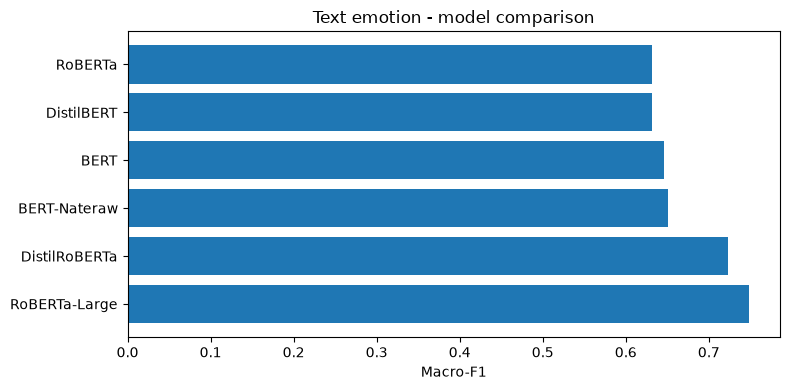

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.barh(comparison_df["Model"], comparison_df["Macro-F1"])
plt.xlabel("Macro-F1")
plt.title("Text emotion - model comparison")
plt.tight_layout()
plt.savefig("text_model_comparison.png")
plt.show()

The average macro-F1 score is the main criterion used to rank the models. Inference time is used as a secondary comparison metric when two models perform similarly. At this point, the testing split has not been used.

## 8 Comparing and Selecting the Best Model

To see where each model does well or poorly, the validation data for each emotion are shown. Inference time is used as a secondary metric, and the candidates are ranked according to their average macro-F1 score. The candidate with the highest ranking is chosen for the final test.

In [29]:
emotion_results = validation_results_df[
    [
        "model",
        "emotion",
        "threshold",
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "inference_time"
    ]
].sort_values(["model", "emotion"])

In [30]:
emotion_results

,model,emotion,threshold,accuracy,macro_precision,macro_recall,macro_f1,inference_time
5,BERT,anger,0.50,0.678571,0.703581,0.674135,0.664844,0.109585
6,BERT,fear,0.01,0.660482,0.662609,0.661959,0.660365,0.969196
7,BERT,joy,0.75,0.728477,0.730395,0.726754,0.726751,0.958533
8,BERT,sadness,0.01,0.692521,0.691303,0.685683,0.686507,0.774916
9,BERT,surprise,0.01,0.519608,0.524614,0.519608,0.493873,0.130538
20,BERT-Nateraw,anger,0.38,0.678571,0.703581,0.674135,0.664844,0.254684
21,BERT-Nateraw,fear,0.04,0.636364,0.635822,0.635125,0.635157,1.098890
22,BERT-Nateraw,joy,0.91,0.713576,0.714507,0.714359,0.713569,0.882804
23,BERT-Nateraw,sadness,0.06,0.700831,0.700074,0.701484,0.700000,0.766780
24,BERT-Nateraw,surprise,0.01,0.568627,0.592727,0.568627,0.538651,0.132886


In [31]:
selected_model_name = comparison_df.loc[0, "Model"]
selected_model_details = models[selected_model_name]
selected_thresholds = model_thresholds[selected_model_name]

In [32]:
print("Selected model:", selected_model_name)
print("Model ID:", selected_model_details["model_id"])
print("\nSelected thresholds:")
for emotion, threshold in selected_thresholds.items():
    print(f"{emotion}: {threshold:.2f}")

Selected model: RoBERTa-Large
Model ID: j-hartmann/emotion-english-roberta-large

Selected thresholds:
anger: 0.05
fear: 0.01
joy: 0.14
sadness: 0.08
surprise: 0.06


The threshold for fear reached the lower search boundary of 0.01. This indicates that the probability outputs of the original single-label classifier are not directly calibrated for CancerEmo's binary emotion labels. This mismatch is therefore treated as a limitation. The selected model achieved the highest overall validation ranking. Its emotion-specific validation thresholds are retained and applied unchanged to the reserved testing split.

## 9 Final Test Evaluation

Only the selected model is evaluated on the reserved CancerEmo testing split. The validation data's emotion-specific thresholds are used just as they were. This provides an unbiased estimate of how the selected model performs on unseen data.

In [33]:
test_evaluation = evaluate_model(selected_model_name, selected_model_details, testing_data, "testing", fixed_thresholds=selected_thresholds)
test_results_df = test_evaluation["results"]
test_predictions = test_evaluation["predictions"]

Device set to use cuda:0


In [34]:
test_results_df[["emotion", "threshold", "accuracy", "macro_precision", "macro_recall", "macro_f1", "inference_time"]]

,emotion,threshold,accuracy,macro_precision,macro_recall,macro_f1,inference_time
0,anger,0.05,0.821429,0.849964,0.788824,0.800853,0.672667
1,fear,0.01,0.703154,0.713016,0.694740,0.693218,4.424062
2,joy,0.14,0.811570,0.814725,0.811320,0.811008,4.793629
3,sadness,0.08,0.664820,0.665047,0.664764,0.664655,3.246711
4,surprise,0.06,0.690909,0.691162,0.690909,0.690807,0.852769


In [35]:
test_summary_df = pd.DataFrame([
    {
        "Selected Model": selected_model_name,

        "Average Accuracy": (test_results_df["accuracy"].mean()),
        "Average Macro Precision": (test_results_df["macro_precision"].mean()),
        "Average Macro Recall": (test_results_df["macro_recall"].mean()),
        "Average Macro-F1": (test_results_df["macro_f1"].mean()),
        "Loading Time": (test_evaluation["loading_time"]),
        "Inference Time": (test_evaluation["inference_time"])
    }
])

In [36]:
test_summary_df

,Selected Model,Average Accuracy,Average Macro Precision,Average Macro Recall,Average Macro-F1,Loading Time,Inference Time
0,RoBERTa-Large,0.738376,0.746783,0.730111,0.732108,2.413503,13.989838


The chosen model's average testing performance and performance for each emotion are shown in the table. Since the testing data was not used for threshold selection or model comparison, these findings represent the final text-model evaluation.

## 10 Confusion Matrices

To display the number of accurate and inaccurate predictions generated by the chosen model on the testing data, a confusion matrix is made for each emotion. Compared to the overall evaluation measures, this offers additional information.

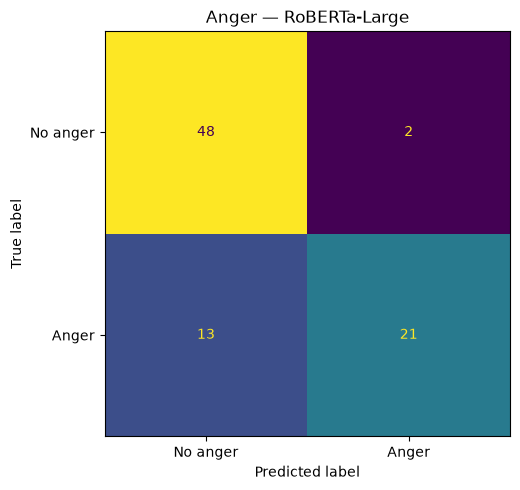

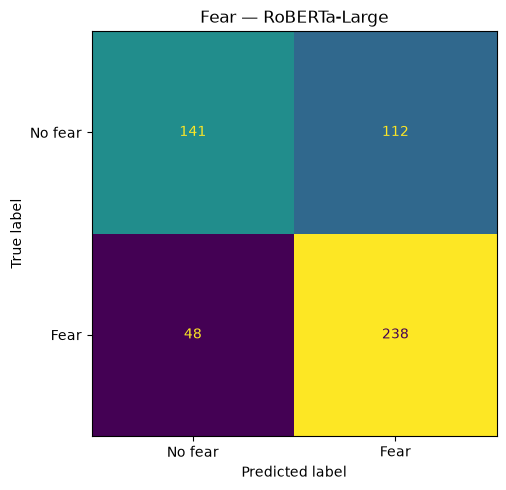

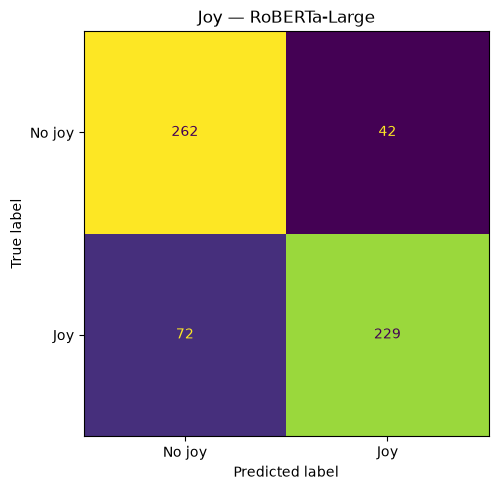

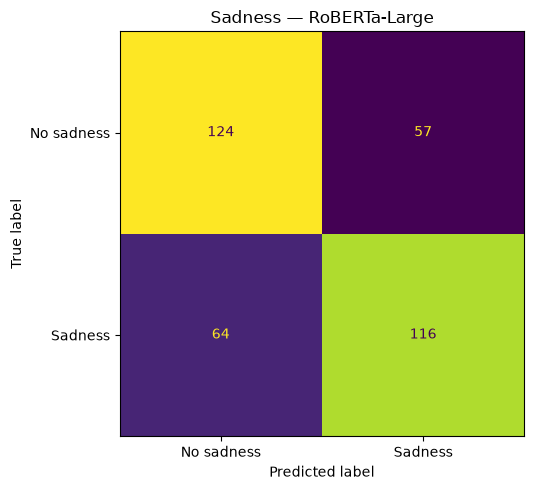

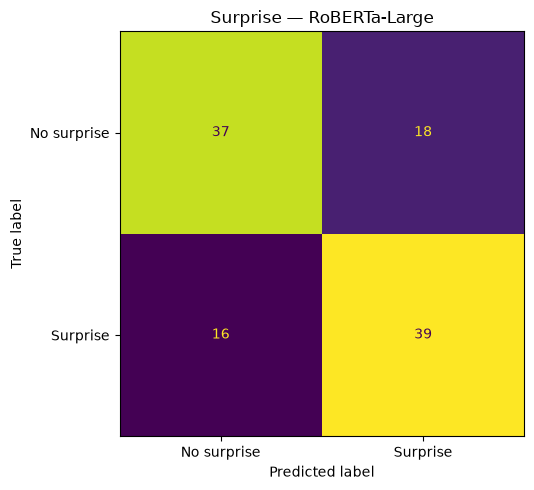

In [37]:
for emotion in emotions:
    values = test_predictions[emotion]
    figure, axis = plt.subplots(figsize=(6, 5))

    ConfusionMatrixDisplay.from_predictions(values["actual"], values["predicted"], display_labels=[f"No {emotion}", emotion.capitalize()], ax=axis, colorbar=False)

    axis.set_title(f"{emotion.capitalize()} — {selected_model_name}")

    plt.tight_layout()
    plt.savefig(output_folder/ f"{emotion}_confusion_matrix.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

The confusion matrices show how well the chosen model can differentiate between each emotion's presence and absence. Additionally, they show whether the majority of errors are false-positive or false-negative predictions.

## 11 Saving Evaluation Results

CSV files are used to store the validation comparison, emotion-level results, and final testing results. This keeps the experimental data safe for use in the final report and subsequent analysis.

In [38]:
validation_results_df.to_csv(output_folder/ "validation_results_by_emotion.csv",index=False)
comparison_df.to_csv(output_folder/ "text_model_comparison.csv",index=False)
test_results_df.to_csv(output_folder/ "selected_model_test_results.csv",index=False)
test_summary_df.to_csv(output_folder/ "selected_model_test_summary.csv",index=False)
print("Results saved in:", output_folder)

Results saved in: outputs\text


The evaluation tables were successfully stored in the output folder for the text model. These files include a record of the final test performance, chosen thresholds, and model comparison.

## 12 Conclusion

The CancerEmo validation data was used to compare six pretrained text-emotion models. RoBERTa-Large was chosen as the final text model because it achieved the highest validation macro-F1 score of 0.7483.

RoBERTa-Large obtained an average macro-F1 score of 0.7321 and an average accuracy of 0.7384 on the reserved testing data. Its strongest results were obtained for joy and anger, while sadness produced the lowest macro-F1 score. Overall, the testing and validation results were similar, suggesting that the chosen model performed reasonably well when applied to previously unseen records. At approximately 5.39 ms per evaluated sentence on the available GPU, the model was sufficiently fast for the application's periodic wellbeing check-ins. CPU deployment may result in a larger processing-time difference.

The final multimodal wellbeing-monitoring application will consequently use RoBERTa-Large as the text-emotion model. The evaluation was limited to anger, fear, joy, sadness and surprise because these were the five emotion labels shared by all six candidate models.